In [209]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

# Load data
df = pd.read_excel(r"C:\Users\Aamir choudhary\OneDrive\Desktop\German_Credit-1 (1).xlsx")

df.head(3)

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education


In [210]:
df.tail()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV
999,27,male,moderate,moderate,4576,45,0,car


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Saving accounts   1000 non-null   object
 3   Checking account  1000 non-null   object
 4   Credit amount     1000 non-null   int64 
 5   Duration          1000 non-null   int64 
 6   Risk              1000 non-null   int64 
 7   Purpose           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [13]:
df.describe()

,Age,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000,0.300000
std,11.375469,2822.736876,12.058814,0.458487
min,19.000000,250.000000,4.000000,0.000000
25%,27.000000,1365.500000,12.000000,0.000000
50%,33.000000,2319.500000,18.000000,0.000000
75%,42.000000,3972.250000,24.000000,1.000000
max,75.000000,18424.000000,72.000000,1.000000


The dataset contains 1000 customer records with financial attributes such as Age, Credit Amount, Duration, and Risk (target variable).

In [14]:
df.isna().sum()

Age                 0
Sex                 0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Risk                0
Purpose             0
dtype: int64

🧾 1. Dataset Overview

Summary
The dataset consists of 1,000 customer records containing demographic and financial attributes such as age, credit amount, loan duration, and account details. The target variable represents the credit risk classification (low risk vs high risk).

Insight
The dataset is well-structured with no missing values and includes a mix of numerical and categorical variables, making it suitable for machine learning modeling.

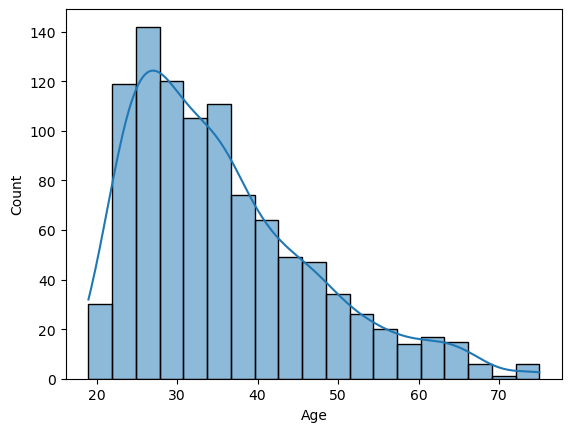

In [18]:
sns.histplot(df['Age'], kde=True)
plt.show()

📈 1. Age Distribution (Histogram + KDE)
✅ Summary

The age distribution is slightly right-skewed, with the majority of customers concentrated between 25 and 40 years.

💡 Insight

This indicates that most borrowers belong to the economically active population segment, which is typically more engaged in credit-based financial activities.

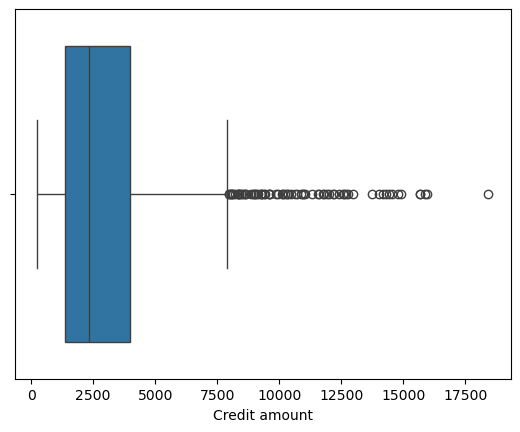

In [19]:
sns.boxplot(x=df['Credit amount'])
plt.show()

📦 2. Credit Amount (Boxplot — Before Capping)
✅ Summary

The credit amount distribution shows a wide spread with multiple extreme outliers on the higher end.

💡 Insight

The presence of high-value outliers suggests variability in loan sizes and highlights the need for outlier treatment to avoid model bias.

In [74]:
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df

cols = ['Credit amount', 'Duration', 'Age']
df = cap_outliers(df, cols)

🛠 4. Outlier Treatment

Summary
Outliers were handled using the Interquartile Range (IQR) method to cap extreme values.

Insight
This step improves model robustness and prevents high-value anomalies from disproportionately influencing model training.

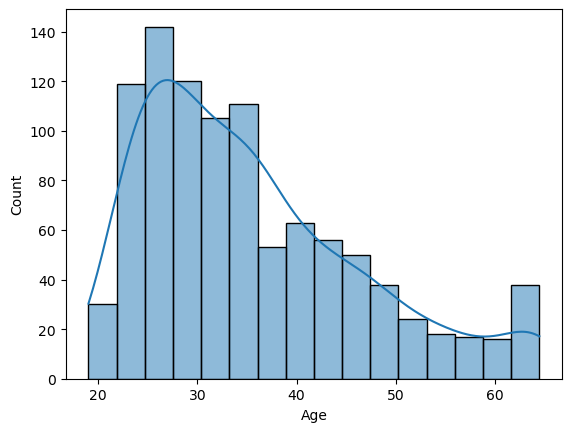

In [75]:
sns.histplot(df['Age'], kde=True)
plt.show()

📊 4. Age Distribution (After Transformation)
✅ Summary

The age distribution remains consistent after preprocessing, with minor smoothing.

💡 Insight

The transformation ensures that the model interprets age more effectively without being influenced by skewness.

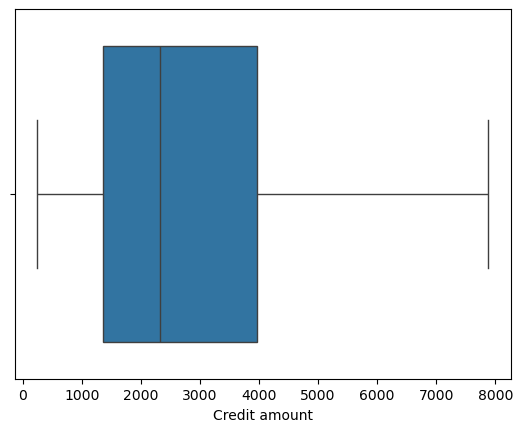

In [76]:
sns.boxplot(x=df['Credit amount'])
plt.show()

📦 3. Credit Amount (After Outlier Capping)
✅ Summary

After applying IQR-based capping, the distribution becomes more compact and less skewed.

💡 Insight

Capping reduces the impact of extreme values, leading to a more stable and generalizable model.

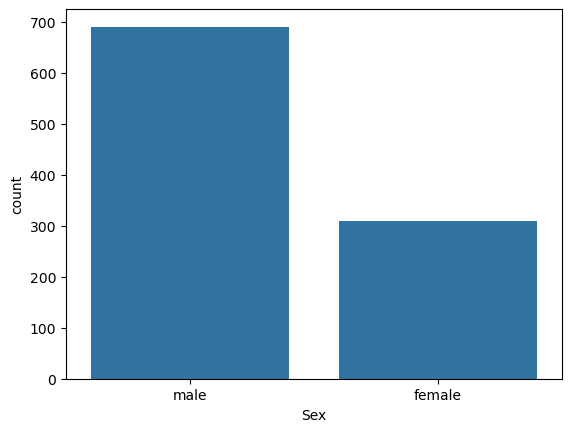

In [20]:
sns.countplot(x='Sex', data=df)
plt.show()

👨‍👩‍👧 5. Gender Distribution (Countplot)
✅ Summary

The dataset shows a higher proportion of male customers compared to female customers.

💡 Insight

This imbalance may introduce bias in predictions, making it important to evaluate model fairness across gender groups.

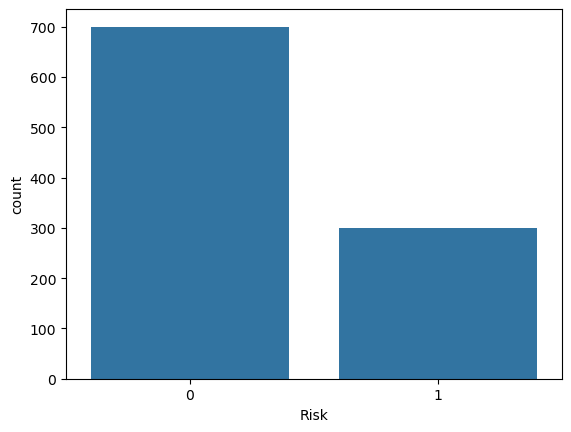

In [21]:
sns.countplot(x='Risk', data=df)
plt.show()

⚠ 6. Risk Distribution (Countplot)
✅ Summary

Low-risk customers significantly outnumber high-risk customers.

💡 Insight

The dataset is imbalanced, which can lead the model to favor the majority class unless handled properly using techniques like class weighting.

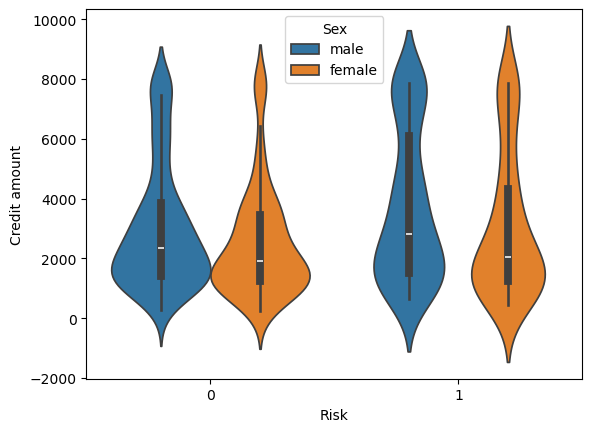

In [64]:
sns.violinplot(x='Risk',y='Credit amount',data=df,hue='Sex')
plt.show()

🎻 7. Credit Amount vs Risk (Violin Plot)
✅ Summary

The distribution of credit amount is higher and more spread out for high-risk customers.

💡 Insight

Higher loan amounts are associated with increased default probability, making credit amount a key risk indicator.

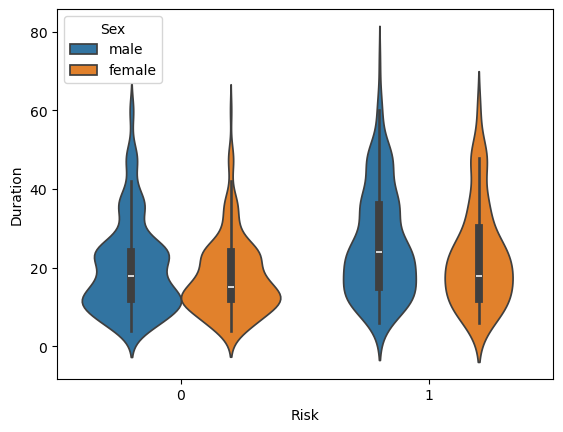

In [65]:
sns.violinplot(x='Risk',y='Duration',data=df,hue='Sex')
plt.show()

🎻 8. Duration vs Risk (Violin Plot)
✅ Summary

Loan duration tends to be longer for high-risk customers.

💡 Insight

Longer repayment periods increase uncertainty and default risk, making duration a critical predictive feature.

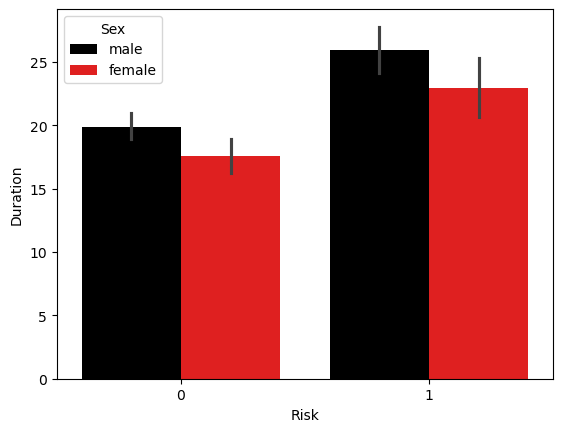

In [66]:
sns.barplot(x='Risk',y='Duration',data=df,palette=['black','red'],hue='Sex')
plt.show()

📊 9. Duration vs Risk (Bar Plot with Gender Split)
✅ Summary

Average loan duration is higher for high-risk customers across both genders.

💡 Insight

The trend is consistent regardless of gender, indicating that duration is a strong independent risk factor.

<Axes: xlabel='Duration', ylabel='Credit amount'>

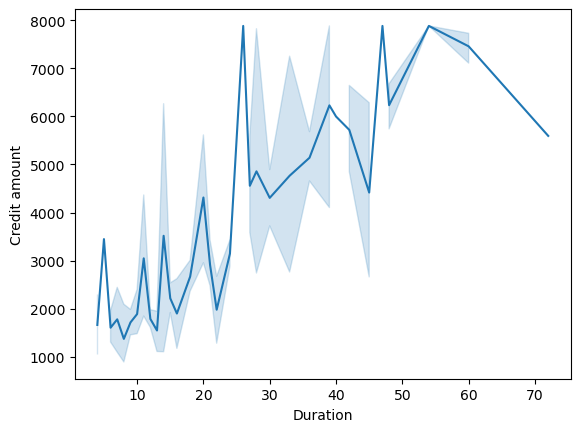

In [67]:
sns.lineplot(x='Duration',y='Credit amount',data=df)

📈 10. Duration vs Credit Amount (Line Plot)
✅ Summary

An upward trend is observed between loan duration and credit amount.

💡 Insight

Higher loan amounts typically require longer repayment periods, reflecting a direct financial dependency between these variables.

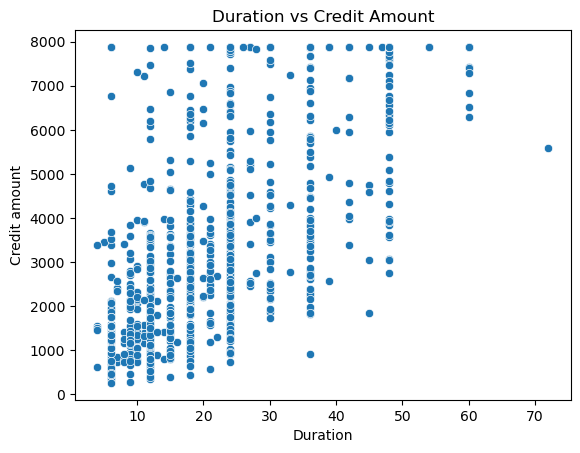

In [68]:
sns.scatterplot(x='Duration', y='Credit amount', data=df)
plt.title("Duration vs Credit Amount")
plt.show()

🔵 11. Duration vs Credit Amount (Scatter Plot)
✅ Summary

The scatter plot shows a positive relationship with some dispersion.

💡 Insight

Although a general trend exists, variability suggests that other factors also influence credit amount.

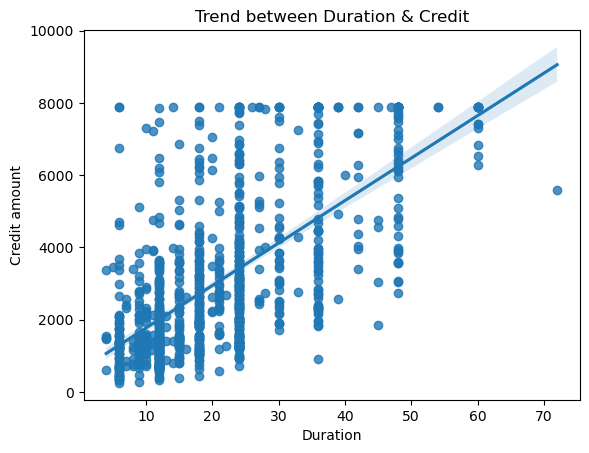

In [69]:
sns.regplot(x='Duration', y='Credit amount', data=df)
plt.title("Trend between Duration & Credit")
plt.show()

📉 12. Duration vs Credit Amount (Regression Plot)
✅ Summary

The regression line confirms a positive correlation between duration and credit amount.

💡 Insight

This relationship supports the financial logic that larger loans are repaid over longer durations.

<Axes: xlabel='Risk', ylabel='Age_Credit_Ratio'>

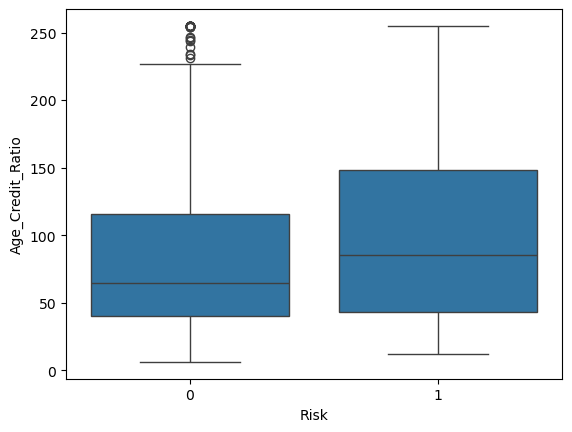

In [73]:
sns.boxplot(x='Risk', y='Age_Credit_Ratio', data=df)

📦 13. Age Credit Ratio vs Risk (Boxplot)
✅ Summary

The Age_Credit_Ratio differs across risk categories, with higher variability in high-risk customers.

💡 Insight

Younger individuals taking larger loans tend to fall into the higher risk category, validating the usefulness of this engineered feature.

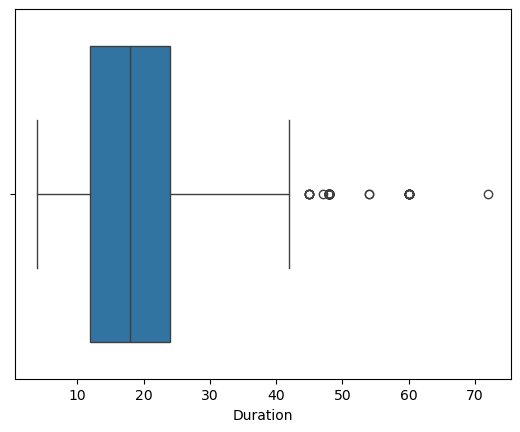

In [71]:
sns.boxplot(x=df['Duration'])
plt.show()

📦 14. Duration (Boxplot)
✅ Summary

Loan duration shows a wide range with some extreme values.

💡 Insight

Outliers in duration indicate irregular repayment structures, which can influence model predictions.

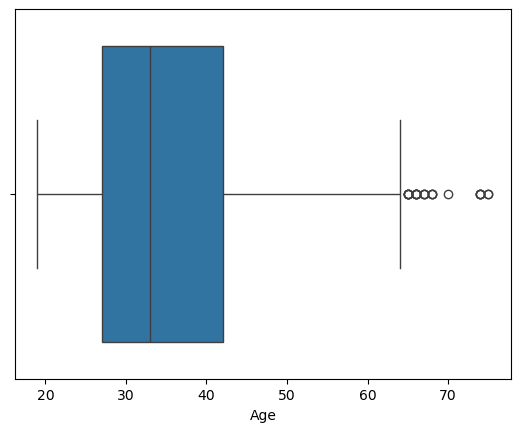

In [72]:
sns.boxplot(x=df['Age'])
plt.show()

📦 15. Age (Boxplot)
✅ Summary

Age distribution is relatively stable but contains a few higher-end outliers.

💡 Insight

Older individuals may have different risk profiles, which should be considered during modeling.

In [211]:
import numpy as np

df['Age_Credit_Ratio'] = np.where(
    df['Credit amount'] != 0,
    df['Age'] / df['Credit amount'],
    0
)

df['Credit_per_month'] = np.where(
    df['Duration'] != 0,
    df['Credit amount'] / df['Duration'],
    0
)

🧠 10. Feature Engineering

Summary
New features such as Age_Credit_Ratio and Credit_per_month were created to capture deeper relationships between variables.

Insight
Feature engineering enhances the model’s ability to identify hidden patterns and improves predictive performance.

In [212]:
   # safety

X = df.drop('Risk', axis=1)   # target check karo
y = df['Risk']

⚙️ 🔥 1️⃣ Data Split (X, y)
✅ Summary
TThe dataset is divided into input features (X) and the target variable (y), where 'Risk' represents the classification label.
💡 Insight
Separating features and target ensures a clear distinction between independent variables and the prediction objective.

In [213]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

🔍 2️⃣ Feature Type Separation
✅ Summary
Features are categorized into numerical and categorical variables based on their data types.
💡 Insight
This separation allows the application of appropriate preprocessing techniques tailored to each feature type.

In [214]:
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

🛠 3️⃣ Numerical Pipeline
✅ Summary
A preprocessing pipeline is applied to numerical features, including median imputation for missing values and standard scaling.
💡 Insight
Scaling ensures that all numerical features contribute equally to the model, preventing bias due to magnitude differences.

In [215]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

🔤 4️⃣ Categorical Pipeline
✅ Summary
Categorical features are processed using most frequent imputation and OneHotEncoding.
💡 Insight
Encoding transforms categorical data into a numerical format, enabling the model to interpret categorical relationships.

In [216]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

🔗 5️⃣ ColumnTransformer (Preprocessor)
✅ Summary
A ColumnTransformer is used to combine numerical and categorical preprocessing pipelines into a unified transformation process.
💡 Insight
This ensures consistent preprocessing across all features and simplifies the model pipeline.

In [217]:
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1])
    ))
])

🤖 6️⃣ Model Integration (XGBoost Pipeline)
✅ Summary
An XGBoost classifier is integrated into the pipeline along with preprocessing steps to form a complete end-to-end model.
💡 Insight
Combining preprocessing and modeling into a single pipeline prevents data leakage and ensures reproducibility.

⚖️ 7️⃣ Class Imbalance Handling
✅ Summary
The scale_pos_weight parameter is used to handle class imbalance by assigning higher importance to the minority class.
💡 Insight
This improves the model’s ability to correctly identify high-risk customers.

In [218]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

✂️ 8️⃣ Train-Test Split
✅ Summary
The dataset is split into training and testing sets using an 80-20 ratio.
💡 Insight
This ensures that the model is evaluated on unseen data, providing a realistic estimate of performance.

In [219]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
}
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


🔍 9️⃣ Hyperparameter Tuning (GridSearchCV)
✅ Summary
GridSearchCV is used to optimize model hyperparameters such as n_estimators, max_depth, and learning_rate.
💡 Insight
Hyperparameter tuning enhances model performance by finding the most optimal config

In [220]:
best_model = grid.best_estimator_

🏆 🔟 Best Model Selection
✅ Summary
The best-performing model is selected based on cross-validation results.
💡 Insight
Using cross-validation ensures that the selected model generalizes well across differen

In [221]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

📊 1️⃣1️⃣ Prediction & Probability
✅ Summary
The trained model is used to generate predictions and corresponding probability scores for the test data.
💡 Insight
Probability scores provide a confidence measure for each prediction, which is crucial in risk-based decision-making.

In [222]:
from sklearn.metrics import classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.66
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       141
           1       0.43      0.51      0.47        59

    accuracy                           0.66       200
   macro avg       0.61      0.62      0.61       200
weighted avg       0.68      0.66      0.67       200



📈 1️⃣2️⃣ Classification Report
✅ Summary
The classification report evaluates model performance using precision, recall, and F1-score.
💡 Insight
Recall is particularly important in this context, as identifying high-risk customer

🎯 1️⃣3️⃣ Accuracy Score
✅ Summary
Accuracy measures the overall proportion of correct predictions made by the model.
💡 Insight
Accuracy alone may not be sufficient for imbalanced datasets, as it can be misleading

In [223]:
from sklearn.metrics import roc_auc_score

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.6943142204591898


📊 1️⃣4️⃣ ROC-AUC Score
✅ Summary
ROC-AUC evaluates the model’s ability to distinguish between classes across different thresholds.
💡 Insight
A higher ROC-AUC indicates better separability between low-risk and high-risk customers.

In [224]:
from sklearn.metrics import average_precision_score

print("PR AUC:", average_precision_score(y_test, y_prob))

PR AUC: 0.48477625941430247


📉 1️⃣5️⃣ PR-AUC Score
✅ Summary
Precision-Recall AUC focuses on the performance of the positive class (high-risk customers).
💡 Insight
PR-AUC is more informative than ROC-AUC when dealing with imbalanced datasets.

In [225]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

best_t, best_f1 = 0, 0

for t in thresholds:
    preds = (y_prob > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)

Best Threshold: 0.45000000000000007


🎚 1️⃣6️⃣ Threshold Optimization
✅ Summary
Different probability thresholds are evaluated to identify the optimal decision boundary based on F1-score.
💡 Insight
Adjusting the threshold improves the balance between precision and recall, especially for

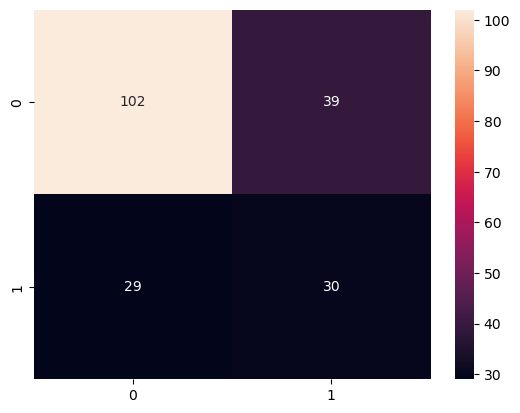

In [226]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

🔲 1️⃣7️⃣ Confusion Matrix
✅ Summary
The confusion matrix visualizes the model’s classification results in terms of true positives, true negatives, false positives, and false negatives.
💡 Insight
False negatives are the most critical errors, as they represent high-risk customers in

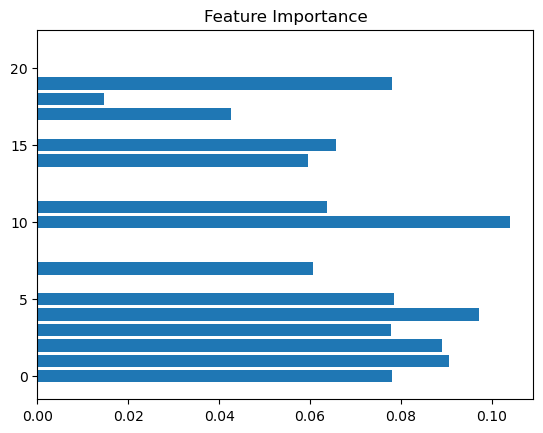

In [227]:
import matplotlib.pyplot as plt

model = best_model.named_steps['model']
importances = model.feature_importances_

plt.barh(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

📊 1️⃣8️⃣ Feature Importance
✅ Summary
Feature importance analysis identifies which variables contribute most to the model’s predictions.
💡 Insight
Key features such as credit amount, duration, and account status play a dominant ro

In [228]:
LogisticRegression(class_weight='balanced', max_iter=1000)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [231]:
!pip install joblib

In [233]:
import joblib

joblib.dump(best_model, "credit_model.pkl")

['credit_model.pkl']

💾 1️⃣9️⃣ Model Saving (joblib)
✅ Summary
The trained model is saved using joblib for future use and deployment.
💡 Insight
Saving the model allows it to be reused without retraining, enabling real-time pr

In [234]:
import os
print(os.getcwd())

C:\Users\Aamir choudhary


📂 2️⃣0️⃣ Working Directory Check
✅ Summary
The current working directory is verified to ensure the model file is saved in the correct location.
💡 Insight
This helps avoid file path errors during deployment and application integration.

FINAL PROFESSIONAL FLOW SUMMARY

An end-to-end machine learning pipeline was developed for credit risk prediction. 
The workflow included data preprocessing, feature engineering, handling class imbalance, and model training using XGBoost. 
Hyperparameter tuning was performed using GridSearchCV to optimize performance. 
The model was evaluated using multiple metrics including ROC-AUC and PR-AUC to ensure robustness in an imbalanced setting. 
Threshold optimization was applied to improve classification effectiveness. 
Finally, the model was saved for deployment and integrated into a Streamlit application for real-time predictions and interpretability.

FINAL PROFESSIONAL CHALLENGE SUMMARY

During the project, several challenges were encountered, including class imbalance, outliers, suboptimal model thresholds, and deployment-related issues such as missing dependencies and model loading errors. 
These challenges were systematically addressed using techniques like feature engineering, IQR-based outlier handling, class weighting, hyperparameter tuning, and threshold optimization. 
Additionally, interpretability methods were introduced to better understand model decisions. 
Overall, resolving these challenges significantly improved model performance, robustness, and deployment readiness.

🧾 Credit Risk Prediction System

End-to-End Machine Learning Project

1. 📌 Objective

The objective of this project is to build an end-to-end machine learning system that predicts whether a loan applicant is low-risk or high-risk based on demographic and financial attributes. The solution also provides probability-based risk scores and interpretability for decision support.

2. 📊 Dataset Description
Records: 1000 customers
Target Variable: Risk (0 = Low Risk, 1 = High Risk)
Features:
Numerical: Age, Credit Amount, Duration
Categorical: Sex, Saving Accounts, Checking Account, Purpose

Data Quality:

No missing values initially
Mix of numerical and categorical variables
Class imbalance present (more low-risk than high-risk)
3. 🔍 Exploratory Data Analysis (EDA)
Key Findings
Age Distribution: Majority between 25–40 years (economically active segment)
Credit Amount: Highly skewed with extreme outliers
Risk Distribution: Imbalanced dataset (low-risk dominates)
Credit Amount vs Risk: Higher loan amounts → higher default risk
Duration vs Risk: Longer loans → higher risk
Duration vs Credit: Positive relationship (larger loans → longer duration)
4. 🛠 Data Preprocessing
Outlier Handling: IQR-based capping for numerical features
Feature Scaling: StandardScaler for numerical variables
Categorical Encoding: OneHotEncoder
Missing Value Handling:
Numerical → Median imputation
Categorical → Most frequent imputation
5. 🧠 Feature Engineering

Two new features were created:

Age_Credit_Ratio = Age / Credit Amount
Credit_per_month = Credit Amount / Duration

Impact:
These features capture deeper financial relationships and improve predictive performance.

6. ⚙️ Machine Learning Pipeline

A robust pipeline was built using:

ColumnTransformer → Handles preprocessing
Pipeline → Combines preprocessing + model

This ensures:

No data leakage
Consistent transformations
Easy deployment
7. 🤖 Model Selection
Model Used: XGBoost Classifier

Why XGBoost?

High performance on tabular data
Handles nonlinear relationships
Works well with imbalanced datasets
8. ⚖️ Handling Class Imbalance
Used: scale_pos_weight in XGBoost
Goal: Improve detection of high-risk customers
9. 🔍 Hyperparameter Tuning

Used GridSearchCV with parameters:

n_estimators
max_depth
learning_rate

Scoring Metric: ROC-AUC
Cross-validation: 5-fold

10. 📊 Model Evaluation
Key Metrics:
Accuracy: ~0.66
ROC-AUC: ~0.69+
PR-AUC: ~0.48
Interpretation:
Model performs reasonably well
ROC-AUC confirms good class separation
PR-AUC highlights challenges due to imbalance
11. 🎯 Threshold Optimization
Default threshold (0.5) was not optimal
Best threshold ≈ 0.45

Benefit:
Improved balance between precision and recall for high-risk detection.

12. 🔲 Confusion Matrix Insights
Model correctly identifies most low-risk customers
Some high-risk customers are missed (false negatives)

Business Impact:
False negatives are critical (bad loans approved)

13. 📊 Feature Importance

Top influencing factors:

Credit Amount
Duration
Checking Account Status
Saving Accounts

Conclusion:
Financial behavior features strongly drive risk prediction.

14. 🧠 Model Explainability
Feature Importance used
SHAP (optional extension) for deep explainability

Purpose:

Understand model decisions
Increase trust in predictions
15. 💻 Deployment (Streamlit App)
Features:
User input panel
Real-time prediction
Risk probability score
Visual gauge chart
Feature importance graph

Outcome:
Interactive UI for non-technical users.

16. ⚠️ Challenges Faced
Key Challenges:
Class imbalance
Outliers in credit amount
Low recall for high-risk class
Threshold selection
Model loading errors (joblib, sklearn)
Dependency issues
Solutions:
Class weighting
IQR outlier capping
Feature engineering
Threshold tuning
Environment consistency
17. 🚀 Final Results
Built a complete end-to-end ML pipeline
Improved prediction using feature engineering + tuning
Created a deployable Streamlit application
Added interpretability for real-world usability
18. 🏆 Conclusion

This project demonstrates a practical implementation of a credit risk prediction system using machine learning. By combining data preprocessing, feature engineering, model optimization, and deployment, the solution provides a scalable and interpretable framework for financial risk assessment.